#Question 9

## Research question
How are sudden spikes in grocery prices reflected in expressions of economic fear and perceived loss of control discussions in Germany?
## Data sources
- Yahoo Finance grocery price data
- Google Trends data for Germany
## Methodological note
This notebook does not measure emotions directly. It uses Google search interest as an observable proxy for public attention related to inflation and food prices.


In [11]:
# Import libraries used for data handling and visualization
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
## 1. File paths

In [13]:
# Define file paths for all datasets used in the analysis
FINANCE_FILE = "yahoo_finance.json"
INFLATION_FILE = "iot_Inflation.json"
FOOD_FILE = "iot_Lebensmittelpreise.json"

In [14]:
## 2. Helper functions

In [15]:
def load_yahoo_json(file_path):
    """
    Load Yahoo Finance data from a JSON file and rename the columns.

    Parameters
    ----------
    file_path : str
        Path to the Yahoo Finance JSON file.

    Returns
    -------
    pandas.DataFrame
        DataFrame with renamed columns.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data)

    rename_map = {
        ('Date', ''): 'date',
        ('Close', 'ZW=F'): 'close',
        ('High', 'ZW=F'): 'high',
        ('Low', 'ZW=F'): 'low',
        ('Open', 'ZW=F'): 'open',
        ('Volume', 'ZW=F'): 'volume',
        ('price_change', ''): 'price_change',
    }

    dataframe = dataframe.rename(columns=rename_map)

    return dataframe


def load_yahoo_json(file_path):
    """
    Load Yahoo Finance data from a JSON file and flatten MultiIndex columns.

    Parameters
    ----------
    file_path : str
        Path to the Yahoo Finance JSON file.

    Returns
    -------
    pandas.DataFrame
        DataFrame with flattened and renamed columns.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data)

    dataframe.columns = [
        '_'.join([str(level) for level in column if level])
        if isinstance(column, (list, tuple))
        else str(column)
        for column in dataframe.columns
    ]

    rename_map = {
        'Date': 'date',
        'Close_ZW=F': 'close',
        'High_ZW=F': 'high',
        'Low_ZW=F': 'low',
        'Open_ZW=F': 'open',
        'Volume_ZW=F': 'volume',
        'price_change': 'price_change',
        'price_change_': 'price_change',
    }

    dataframe = dataframe.rename(columns=rename_map)

    return dataframe

In [16]:
## 3. Load data

In [17]:
# Load all raw datasets.
finance_df = load_yahoo_json(FINANCE_FILE)
inflation_df = load_trends_json(INFLATION_FILE)
food_df = load_trends_json(FOOD_FILE)

In [18]:
finance_df.columns = [
    'index',
    'date',
    'close',
    'high',
    'low',
    'open',
    'volume',
    'price_change'
]

In [19]:
def load_trends_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data['data'])

    return dataframe

In [20]:
print(finance_df.columns)

Index(['index', 'date', 'close', 'high', 'low', 'open', 'volume',
       'price_change'],
      dtype='str')


In [21]:
print (finance_df.columns)
print (finance_df.head())

Index(['index', 'date', 'close', 'high', 'low', 'open', 'volume',
       'price_change'],
      dtype='str')
   index                     date   close    high     low    open  volume  \
0      0  2020-01-02T00:00:00.000  560.25  567.50  558.25  559.50   49931   
1      1  2020-01-03T00:00:00.000  554.50  562.00  551.75  560.75   44180   
2      2  2020-01-06T00:00:00.000  550.00  555.25  546.75  552.50   47904   
3      3  2020-01-07T00:00:00.000  550.25  551.00  545.50  549.50   41346   
4      4  2020-01-08T00:00:00.000  552.75  555.75  545.25  549.50   51322   

   price_change  
0           NaN  
1     -0.010263  
2     -0.008115  
3      0.000455  
4      0.004543  


In [22]:
## 4. Clean data

In [23]:
def clean_finance_data(dataframe):
    """
    Clean the Yahoo Finance dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Raw finance dataframe.

    Returns
    -------
    pandas.DataFrame
        Cleaned finance dataframe.
    """
    dataframe = dataframe.copy()

    dataframe['date'] = pd.to_datetime(dataframe['date'])
    dataframe['close'] = pd.to_numeric(dataframe['close'], errors='coerce')
    dataframe['price_change'] = pd.to_numeric(
        dataframe['price_change'],
        errors='coerce',
    )

    dataframe = dataframe.dropna(subset=['date', 'close'])
    dataframe = dataframe.sort_values('date').reset_index(drop=True)

    return dataframe

In [24]:
def clean_trends_data(dataframe, value_column_name):
    """
    Clean a Google Trends dataframe and rename the trend column.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Raw trends dataframe.
    value_column_name : str
        New name for the trend value column.

    Returns
    -------
    pandas.DataFrame
        Cleaned trends dataframe.
    """
    dataframe = dataframe.copy()

    dataframe['date'] = pd.to_datetime(dataframe['date'])

    trend_column = [column for column in dataframe.columns if column != 'date'][0]

    dataframe = dataframe.rename(columns={trend_column: value_column_name})
    dataframe[value_column_name] = pd.to_numeric(
        dataframe[value_column_name],
        errors='coerce',
    )

    dataframe = dataframe.dropna(subset=['date', value_column_name])
    dataframe = dataframe.sort_values('date').reset_index(drop=True)

    return dataframe

In [25]:
# Clean all datasets before merging them.
finance_df = clean_finance_data(finance_df)
inflation_df = clean_trends_data(inflation_df, 'inflation_interest')
food_df = clean_trends_data(food_df, 'food_price_interest')

In [26]:
## 5. Feature engineering

In [27]:
print (finance_df.columns)
print (inflation_df.columns)
print (food_df.columns)

Index(['index', 'date', 'close', 'high', 'low', 'open', 'volume',
       'price_change'],
      dtype='str')
Index(['date', 'inflation_interest'], dtype='str')
Index(['date', 'food_price_interest'], dtype='str')


In [28]:
def add_time_features(dataframe):
    """
    Add year and month features based on the date column.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input dataframe with a date column.

    Returns
    -------
    pandas.DataFrame
        Dataframe with additional time features.
    """
    dataframe = dataframe.copy()

    dataframe['year'] = dataframe['date'].dt.year
    dataframe['month'] = dataframe['date'].dt.to_period('M').astype(str)

    return dataframe

In [29]:
# Add time-based features for later aggregation and merging.
finance_df = add_time_features(finance_df)
inflation_df = add_time_features(inflation_df)
food_df = add_time_features(food_df)

In [30]:
## 6. Aggregate finance data to monthly level

In [31]:
# Aggregate daily finance data to monthly averages.
monthly_finance_df = (
    finance_df
    .groupby('month', as_index=False)
    .agg(
        avg_close=('close', 'mean'),
        avg_price_change=('price_change', 'mean'),
    )
)

In [32]:
# Keep one monthly observation per Google Trends dataset.
monthly_inflation_df = inflation_df[['month', 'inflation_interest']].copy()
monthly_food_df = food_df[['month', 'food_price_interest']].copy()

In [33]:
## 7. Merge datasets

In [34]:
# Merge monthly finance data with both Google Trends datasets.
analysis_df = (
    monthly_finance_df
    .merge(monthly_inflation_df, on='month', how='left')
    .merge(monthly_food_df, on='month', how='left')
)

In [35]:
## 8. Define price spikes

In [36]:
# Define spike months based on the 90th percentile of monthly price changes.
spike_threshold = analysis_df['avg_price_change'].quantile(0.90)

analysis_df['price_spike'] = (
    analysis_df['avg_price_change'] >= spike_threshold
)

In [37]:
print(f'Spike threshold: {spike_threshold:.4f}')
print(f'Number of spikes: {analysis_df["price_spike"].sum()}')

Spike threshold: 0.0047
Number of spikes: 6


In [38]:
## 9. Compare spike and non-spike months

In [39]:
# Compare average search interest between spike and non-spike months.
spike_summary = (
    analysis_df
    .groupby('price_spike', as_index=False)
    .agg(
        mean_inflation_interest=('inflation_interest', 'mean'),
        mean_food_price_interest=('food_price_interest', 'mean'),
        mean_price_change=('avg_price_change', 'mean'),
    )
)

spike_summary

,price_spike,mean_inflation_interest,mean_food_price_interest,mean_price_change
0,False,41.228704,22.037963,-0.000604
1,True,55.316667,30.100000,0.007439


In [40]:
## 10. Visualizations

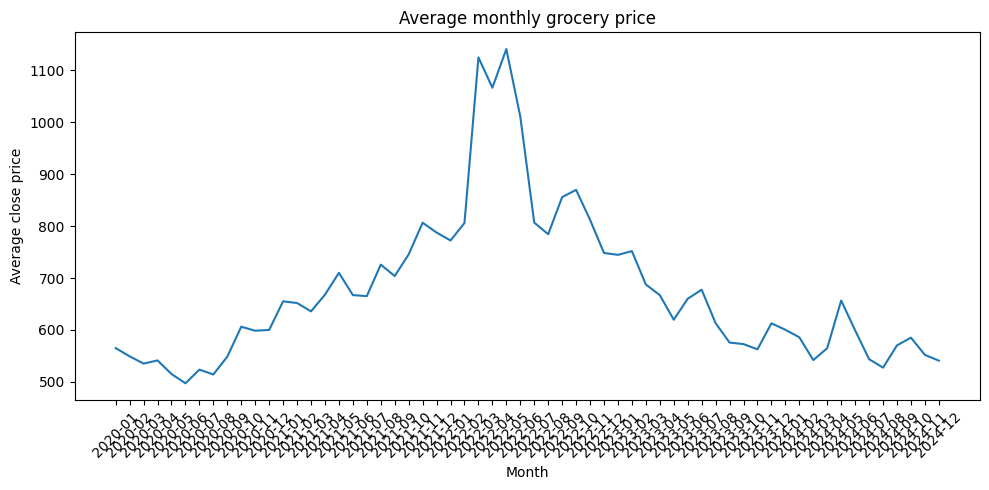

In [41]:
# Plot the average monthly grocery price over time.
plt.figure(figsize=(10, 5))
sns.lineplot(data=analysis_df, x='month', y='avg_close')
plt.xticks(rotation=45)
plt.title('Average monthly grocery price')
plt.xlabel('Month')
plt.ylabel('Average close price')
plt.tight_layout()
plt.show()

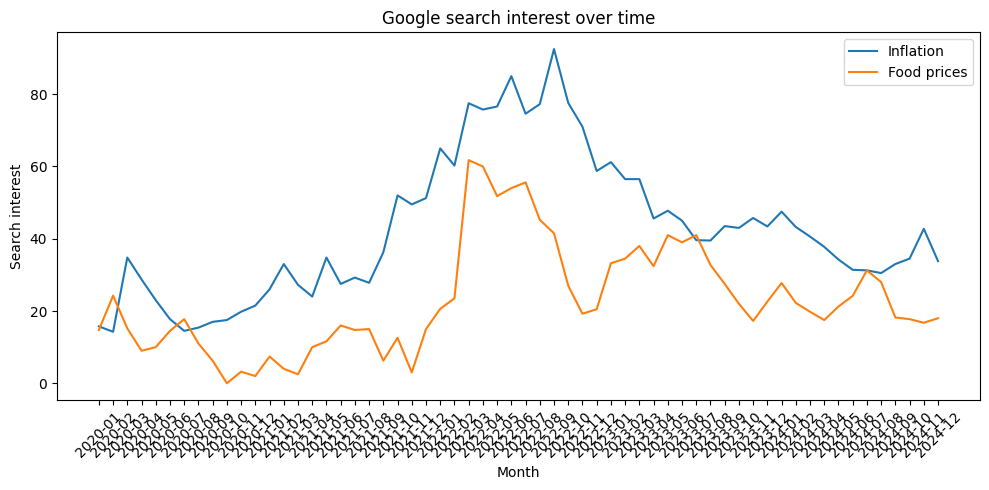

In [42]:
# Plot Google Trends interest over time.
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=analysis_df,
    x='month',
    y='inflation_interest',
    label='Inflation',
)
sns.lineplot(
    data=analysis_df,
    x='month',
    y='food_price_interest',
    label='Food prices',
)
plt.xticks(rotation=45)
plt.title('Google search interest over time')
plt.xlabel('Month')
plt.ylabel('Search interest')
plt.tight_layout()
plt.show()

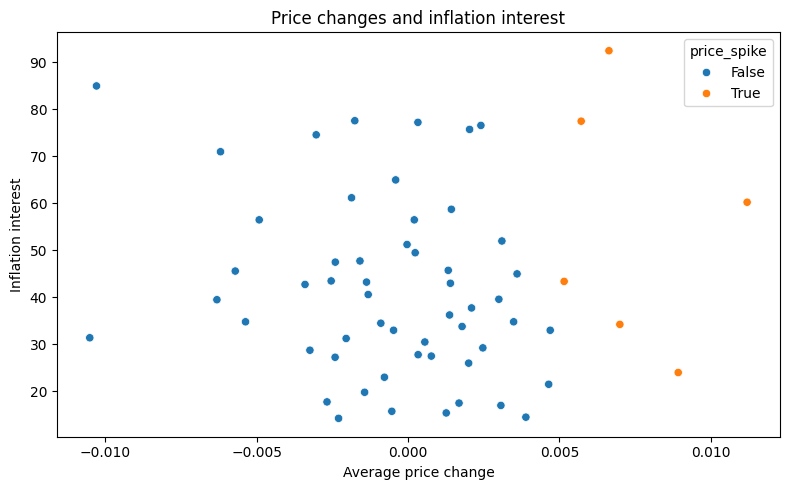

In [43]:
# Show the relationship between price changes and inflation interest.
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=analysis_df,
    x='avg_price_change',
    y='inflation_interest',
    hue='price_spike',
)
plt.title('Price changes and inflation interest')
plt.xlabel('Average price change')
plt.ylabel('Inflation interest')
plt.tight_layout()
plt.show()

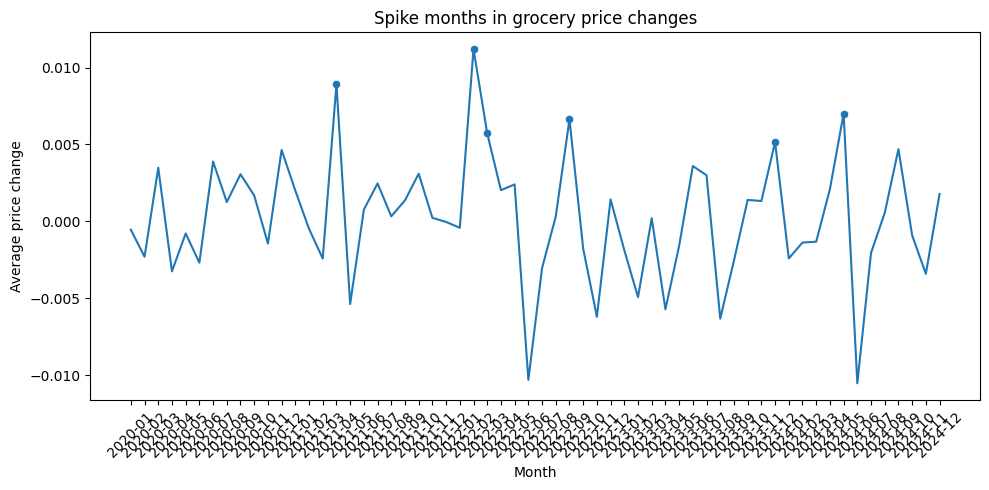

In [44]:
# Highlight spike months in the monthly price change series.
plt.figure(figsize=(10, 5))
sns.lineplot(data=analysis_df, x='month', y='avg_price_change')
sns.scatterplot(
    data=analysis_df[analysis_df['price_spike']],
    x='month',
    y='avg_price_change',
)
plt.xticks(rotation=45)
plt.title('Spike months in grocery price changes')
plt.xlabel('Month')
plt.ylabel('Average price change')
plt.tight_layout()
plt.show()

## 11. Interpretation 
This analysis is exploratory.It shows associations between grocery-price
spikes and Google search interest, but it does not prove causality.
Furthermore, it does not measure emotions directly.Instead, it uses online
search activity as an observable behavioural signal.